Implementing DeepONet. Paper: https://arxiv.org/abs/1910.03193

Main code taken from "elastropy" youtube channel https://www.youtube.com/watch?v=mHLXNGbVhw4&t=17s

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"[INFO] Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"[INFO] CUDA not available -> using CPU")

[INFO] CUDA not available -> using CPU


The example is for 1D Poission Equation

$−u′′(x)=f(x),
x∈(0,1), u(0)=u(1)=0$

for a generic forcing fuction $f(x)$. Here the forcing function is thought of as a polynomial of degree n.

In [2]:
def sample_polynomial_coeffs(batch_size: int, degree: int = 3, scale: float = 0.1):
    # shape: (batch, degree+1)
    # distribution can be changed
    return scale * torch.randn(batch_size, degree + 1, device = device)


def eval_polynomial(coeffs: torch.Tensor, x: torch.Tensor):
    """
    coeffs: (B, D+1)
    x: (N, 1) or (B, N, 1)
    returns f: (B, N, 1)
    """
    B, D1 = coeffs.shape
    D = D1 - 1

    if x.dim() == 2:
        # x: (N, 1) -> broadcast to (B, N, 1)
        x = x.unsqueeze(0).repeat(B, 1, 1)

    # powers: (B, N, D+1)
    powers = torch.cat([x**k for k in range(D + 1)], dim = -1)
    #coeffs: (B, 1, D+1)
    c = coeffs.unsqueeze(1)
    f = (powers * c).sum(dim = -1, keepdim = True)
    return f

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, activation = nn.Tanh):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), activation()]
            prev = h
        layers += [nn.Linear(prev, output_dim)]
        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)


class DeepONet(nn.Module):
    def __init__(self, m_sensors: int, p: int = 32):
        super().__init__()
        # Branch: R^m -> R^p
        self.branch = MLP(input_dim = m_sensors, hidden = [64, 64], output_dim = p, activation = nn.Tanh)
        # Trunk: R^1 -> R^p
        self.trunk = MLP(input_dim = 1, hidden = [64, 64], output_dim = p, activation = nn.Tanh)


    def forward(self, f_sensors, x):
        """
        f_sensors: (B, m)
        x: (N, 1) or (B, N, 1)
        returns u: (B, N, 1)
        """
        B = f_sensors.shape[0]

        # trunk features at x
        if x.dim() == 2:
            # (N, 1) -> (B, N, 1)
            x_in = x.unsqueeze(0).repeat(B, 1, 1)
        else:
            x_in = x

        # (B, p)
        b = self.branch(f_sensors)
        # (B, N, p)
        t = self.trunk(x_in)

        # Dot product over p: (B, N)
        u = (t * b.unsqueeze(1)).sum(dim = -1, keepdim = True)

        # Hard-enforce u(0)=u(1)=0 via output transform:
        # u_hat(x) = x(1-x) * u_row(x)
        u = x_in * (1.0 - x_in) * u
        return u

In [4]:
def second_derivative(u, x):
    """
    u: (B, N, 1) depends on x (B, N, 1) with requries_grad = True
    returns u_xx: (B, N, 1)
    """
    # First derivative
    du_dx = torch.autograd.grad(
        outputs = u,
        inputs = x,
        grad_outputs = torch.ones_like(u),
        create_graph = True,
        retain_graph = True,
    )[0]

    # Second derivative
    d2u_dx2 = torch.autograd.grad(
        outputs = du_dx,
        inputs = x,
        grad_outputs = torch.ones_like(du_dx),
        create_graph = True,
        retain_graph = True,
    )[0]

    return d2u_dx2

In [5]:
torch.manual_seed(0)
np.random.seed(0)

# sensors and collection points
m = 10                         # number of sensors (like DeppXDE eval points)
p = 32                         # latent width in DeepONet
N_domain = 100                 # collection points for PDE residuals
batch_size = 64                # number of functions per step

# fixed sensor locations
x_sensors = torch.linspace(0, 1, m, device = device).view(-1, 1)

# fixed domain collation locations
x_domain = torch.linspace(0, 1, N_domain, device = device).view(-1, 1)

model = DeepONet(m_sensors = m, p = p).to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

# weights
w_pde = 1.0
w_bc = 10.0

In [6]:
def train_step():
    model.train()
    optimizer.zero_grad()

    # sample a batch of random polynomials f
    coeffs = sample_polynomial_coeffs(batch_size = batch_size, degree = 3, scale = 1.0)

    # evaluate f at sensors -> branch input
    f_sensors_vals = eval_polynomial(coeffs, x_sensors).squeeze(-1)    # (B, m)

    # evaluate f on domain points for PDE residuals
    f_domain = eval_polynomial(coeffs, x_domain)        # (B, N, 1)

    # prepare x for autograd
    x_in = x_domain.unsqueeze(0).repeat(batch_size, 1, 1).clone().detach().requires_grad_(True)

    # predict u
    u = model(f_sensors_vals, x_in)    # (B, N, 1)

    # PDE residual: -u_xx = f = 0
    u_xx = second_derivative(u, x_in)
    res = -u_xx - f_domain
    loss_pde = (res ** 2).mean()

    # BC loss (should already be satisfied by transforms, but keep as sanity)
    x0 = torch.zeros(batch_size, 1, 1, device = device, requires_grad = False)
    x1 = torch.ones(batch_size, 1, 1, device = device, requires_grad = False)
    u0 = model(f_sensors_vals, x0)    # (B, 1, 1)
    u1 = model(f_sensors_vals, x1)   # (B, 1, 1)
    loss_bc = (u0 ** 2).mean() + (u1 ** 2).mean()

    loss = (w_pde * loss_pde) + (w_bc * loss_bc)
    loss.backward()
    optimizer.step()

    return loss.item(), loss_pde.item(), loss_bc.item()

In [7]:
# Training Loop

steps = 5000
print_every = 500

for step in range(1, steps + 1):
    loss, lpde, lbc = train_step()
    if step % print_every == 0 or step == 1:
        print(f"Step {step:5d} | loss = {loss: .3e} | pde = {lpde: .3e} | bc = {lbc:.3e}")

Step     1 | loss =  1.855e+00 | pde =  1.855e+00 | bc = 0.000e+00
Step   500 | loss =  1.325e-03 | pde =  1.325e-03 | bc = 0.000e+00
Step  1000 | loss =  5.254e-04 | pde =  5.254e-04 | bc = 0.000e+00
Step  1500 | loss =  6.202e-04 | pde =  6.202e-04 | bc = 0.000e+00
Step  2000 | loss =  5.875e-04 | pde =  5.875e-04 | bc = 0.000e+00
Step  2500 | loss =  1.022e-03 | pde =  1.022e-03 | bc = 0.000e+00
Step  3000 | loss =  1.390e-03 | pde =  1.390e-03 | bc = 0.000e+00
Step  3500 | loss =  1.473e-03 | pde =  1.473e-03 | bc = 0.000e+00
Step  4000 | loss =  9.093e-04 | pde =  9.093e-04 | bc = 0.000e+00
Step  4500 | loss =  4.436e-04 | pde =  4.436e-04 | bc = 0.000e+00
Step  5000 | loss =  2.013e-03 | pde =  2.013e-03 | bc = 0.000e+00


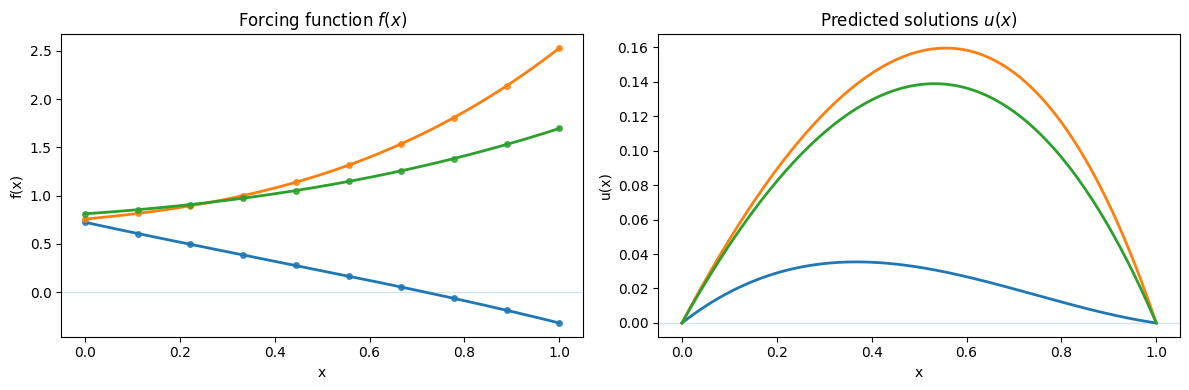

In [8]:
# Visualization of forcing functions and predicted solutions

model.eval()
n_plot = 3

# Sample random forcing functions
coeffs = sample_polynomial_coeffs(batch_size = n_plot, degree = 3, scale = 1.0)
f_sensor_vals = eval_polynomial(coeffs, x_sensors).squeeze(-1)    # (n, m)

# fine grid for plotting
x_plot = torch.linspace(0, 1, 200, device = device).view(-1, 1)

with torch.no_grad():
    u_pred = model(f_sensor_vals, x_plot)   # (n, 200, 1)

# convert to numpy for plotting
u_pred = u_pred.squeeze(-1).cpu().numpy()
f_plot = eval_polynomial(coeffs, x_plot).squeeze(-1).cpu().numpy()

x_plot_np = x_plot.squeeze(-1).cpu().numpy()
x_sensors_np = x_sensors.squeeze(-1).cpu().numpy()
f_sensors_np = eval_polynomial(coeffs, x_sensors).squeeze(-1).cpu().numpy()


# Plot f(x) and u(x) side by side with consistent colors

plt.figure(figsize = (12, 4))

# Left: forcing function
plt.subplot(1, 2, 1)
plt.title("Forcing function $f(x)$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.axhline(0, linewidth = 1, alpha = 0.2)

for i in range(n_plot):
    line, = plt.plot(x_plot_np, f_plot[i], linewidth = 2)
    plt.plot(
        x_sensors_np,
        f_sensors_np[i],
        "o",
        markersize = 4,
        color = line.get_color(),
        alpha = 0.8,
    )

# Right: predicted solutions
plt.subplot(1, 2, 2)
plt.title("Predicted solutions $u(x)$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.axhline(0, linewidth = 1, alpha = 0.2)

for i in range(n_plot):
    plt.plot(x_plot_np, u_pred[i], linewidth = 2)

plt.tight_layout()
plt.show()

Modified code to solve $−u′′(x)=sin(x)$\
This is not operator learning anymore. It is learning a single particular function $sin(x)$

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"[INFO] Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"[INFO] CUDA not available -> using CPU")

[INFO] CUDA not available -> using CPU


In [10]:
def sample_polynomial_coeffs(batch_size: int, degree: int = 3, scale: float = 0.1):
    # shape: (batch, degree+1)
    # distribution can be changed
    return scale * torch.randn(batch_size, degree + 1, device = device)


def eval_polynomial(coeffs: torch.Tensor, x: torch.Tensor):
    """
    coeffs: (B, D+1)
    x: (N, 1) or (B, N, 1)
    returns f: (B, N, 1)
    """
    B, D1 = coeffs.shape
    D = D1 - 1

    if x.dim() == 2:
        # x: (N, 1) -> broadcast to (B, N, 1)
        x = x.unsqueeze(0).repeat(B, 1, 1)

    # powers: (B, N, D+1)
    powers = torch.cat([x**k for k in range(D + 1)], dim = -1)
    #coeffs: (B, 1, D+1)
    c = coeffs.unsqueeze(1)
    f = (powers * c).sum(dim = -1, keepdim = True)
    return f

In [11]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, activation = nn.Tanh):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), activation()]
            prev = h
        layers += [nn.Linear(prev, output_dim)]
        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)


class DeepONet(nn.Module):
    def __init__(self, m_sensors: int, p: int = 32):
        super().__init__()
        # Branch: R^m -> R^p
        self.branch = MLP(input_dim = m_sensors, hidden = [64, 64], output_dim = p, activation = nn.Tanh)
        # Trunk: R^1 -> R^p
        self.trunk = MLP(input_dim = 1, hidden = [64, 64], output_dim = p, activation = nn.Tanh)


    def forward(self, f_sensors, x):
        """
        f_sensors: (B, m)
        x: (N, 1) or (B, N, 1)
        returns u: (B, N, 1)
        """
        B = f_sensors.shape[0]

        # trunk features at x
        if x.dim() == 2:
            # (N, 1) -> (B, N, 1)
            x_in = x.unsqueeze(0).repeat(B, 1, 1)
        else:
            x_in = x

        # (B, p)
        b = self.branch(f_sensors)
        # (B, N, p)
        t = self.trunk(x_in)

        # Dot product over p: (B, N)
        u = (t * b.unsqueeze(1)).sum(dim = -1, keepdim = True)

        # Hard-enforce u(0)=u(1)=0 via output transform:
        # u_hat(x) = x(1-x) * u_row(x)
        u = x_in * (1.0 - x_in) * u
        return u

In [12]:
def second_derivative(u, x):
    """
    u: (B, N, 1) depends on x (B, N, 1) with requries_grad = True
    returns u_xx: (B, N, 1)
    """
    # First derivative
    du_dx = torch.autograd.grad(
        outputs = u,
        inputs = x,
        grad_outputs = torch.ones_like(u),
        create_graph = True,
        retain_graph = True,
    )[0]

    # Second derivative
    d2u_dx2 = torch.autograd.grad(
        outputs = du_dx,
        inputs = x,
        grad_outputs = torch.ones_like(du_dx),
        create_graph = True,
        retain_graph = True,
    )[0]

    return d2u_dx2

In [13]:
torch.manual_seed(0)
np.random.seed(0)

# sensors and collection points
m = 10                         # number of sensors (like DeppXDE eval points)
p = 32                         # latent width in DeepONet
N_domain = 100                 # collection points for PDE residuals
batch_size = 64                # number of functions per step

# fixed sensor locations
x_sensors = torch.linspace(0, 1, m, device = device).view(-1, 1)

# fixed domain collation locations
x_domain = torch.linspace(0, 1, N_domain, device = device).view(-1, 1)

model = DeepONet(m_sensors = m, p = p).to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

# weights
w_pde = 1.0
w_bc = 10.0

In [14]:
def train_step():
    model.train()
    optimizer.zero_grad()

    # # sample a batch of random polynomials f
    # coeffs = sample_polynomial_coeffs(batch_size = batch_size, degree = 3, scale = 1.0)

    # # evaluate f at sensors -> branch input
    # f_sensors_vals = eval_polynomial(coeffs, x_sensors).squeeze(-1)    # (B, m)

    # # evaaluate f on domain points for PDE residuals
    # f_domain = eval_polynomial(coeffs, x_domain)        # (B, N, 1)

    # Fixed forcing function
    '''
    In this case, the model is not learning an operator anymore, it is reduced to
    learning a single function u(x).
    DeepONet becomes an overkill here.
    DeepONet reduces to a PINN when input is fixed.
    '''
    f_sensors_vals = torch.sin(x_sensors).squeeze(-1)    # (m, )
    f_sensors_vals = f_sensors_vals.unsqueeze(0).repeat(batch_size, 1)

    f_domain = torch.sin(x_domain)    # (N, 1)
    f_domain = f_domain.unsqueeze(0).repeat(batch_size, 1, 1)

    # prepare x for autograd
    x_in = x_domain.unsqueeze(0).repeat(batch_size, 1, 1).clone().detach().requires_grad_(True)

    # predict u
    u = model(f_sensors_vals, x_in)    # (B, N, 1)

    # PDE residual: -u_xx - sin(x) = 0
    u_xx = second_derivative(u, x_in)
    res = -u_xx - f_domain
    loss_pde = (res ** 2).mean()

    # BC loss (should already be satisfied by transforms, but keep as sanity)
    x0 = torch.zeros(batch_size, 1, 1, device = device, requires_grad = False)
    x1 = torch.ones(batch_size, 1, 1, device = device, requires_grad = False)
    u0 = model(f_sensors_vals, x0)    # (B, 1, 1)
    u1 = model(f_sensors_vals, x1)   # (B, 1, 1)
    loss_bc = (u0 ** 2).mean() + (u1 ** 2).mean()

    loss = (w_pde * loss_pde) + (w_bc * loss_bc)
    loss.backward()
    optimizer.step()

    return loss.item(), loss_pde.item(), loss_bc.item()

In [15]:
# Training Loop

steps = 5000
print_every = 500

for step in range(1, steps + 1):
    loss, lpde, lbc = train_step()
    if step % print_every == 0 or step == 1:
        print(f"Step {step:5d} | loss = {loss: .3e} | pde = {lpde: .3e} | bc = {lbc:.3e}")

Step     1 | loss =  9.053e-02 | pde =  9.053e-02 | bc = 0.000e+00
Step   500 | loss =  5.031e-07 | pde =  5.031e-07 | bc = 0.000e+00
Step  1000 | loss =  3.939e-07 | pde =  3.939e-07 | bc = 0.000e+00
Step  1500 | loss =  2.744e-07 | pde =  2.744e-07 | bc = 0.000e+00
Step  2000 | loss =  1.663e-07 | pde =  1.663e-07 | bc = 0.000e+00
Step  2500 | loss =  8.419e-08 | pde =  8.419e-08 | bc = 0.000e+00
Step  3000 | loss =  5.210e-06 | pde =  5.210e-06 | bc = 0.000e+00
Step  3500 | loss =  1.360e-07 | pde =  1.360e-07 | bc = 0.000e+00
Step  4000 | loss =  6.571e-06 | pde =  6.571e-06 | bc = 0.000e+00
Step  4500 | loss =  6.361e-08 | pde =  6.361e-08 | bc = 0.000e+00
Step  5000 | loss =  6.617e-08 | pde =  6.617e-08 | bc = 0.000e+00


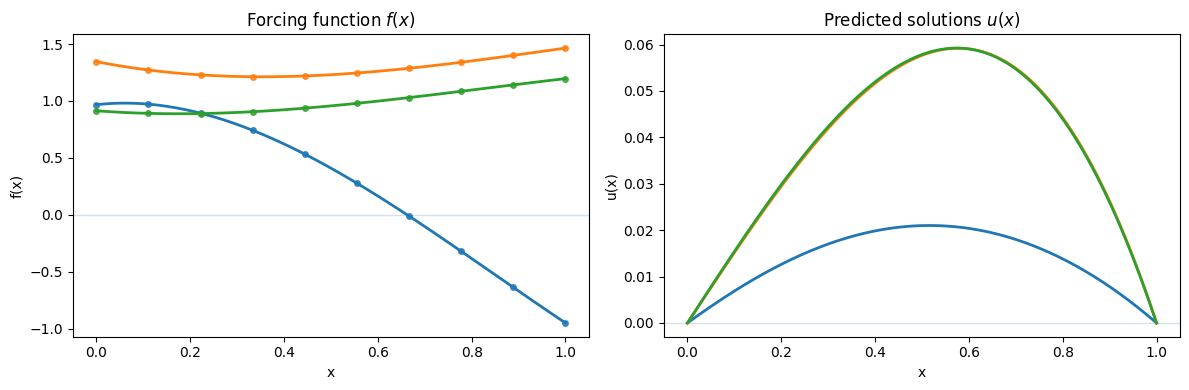

In [16]:
# Visualization of forcing functions and predicted solutions

model.eval()
n_plot = 3

# Sample random forcing functions
coeffs = sample_polynomial_coeffs(batch_size = n_plot, degree = 3, scale = 1.0)
f_sensor_vals = eval_polynomial(coeffs, x_sensors).squeeze(-1)    # (n, m)

# fine grid for plotting
x_plot = torch.linspace(0, 1, 200, device = device).view(-1, 1)

with torch.no_grad():
    u_pred = model(f_sensor_vals, x_plot)   # (n, 200, 1)

# convert to numpy for plotting
u_pred = u_pred.squeeze(-1).cpu().numpy()
f_plot = eval_polynomial(coeffs, x_plot).squeeze(-1).cpu().numpy()

x_plot_np = x_plot.squeeze(-1).cpu().numpy()
x_sensors_np = x_sensors.squeeze(-1).cpu().numpy()
f_sensors_np = eval_polynomial(coeffs, x_sensors).squeeze(-1).cpu().numpy()


# Plot f(x) and u(x) side by side with consistent colors

plt.figure(figsize = (12, 4))

# Left: forcing function
plt.subplot(1, 2, 1)
plt.title("Forcing function $f(x)$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.axhline(0, linewidth = 1, alpha = 0.2)

for i in range(n_plot):
    line, = plt.plot(x_plot_np, f_plot[i], linewidth = 2)
    plt.plot(
        x_sensors_np,
        f_sensors_np[i],
        "o",
        markersize = 4,
        color = line.get_color(),
        alpha = 0.8,
    )

# Right: predicted solutions
plt.subplot(1, 2, 2)
plt.title("Predicted solutions $u(x)$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.axhline(0, linewidth = 1, alpha = 0.2)

for i in range(n_plot):
    plt.plot(x_plot_np, u_pred[i], linewidth = 2)

plt.tight_layout()
plt.show()

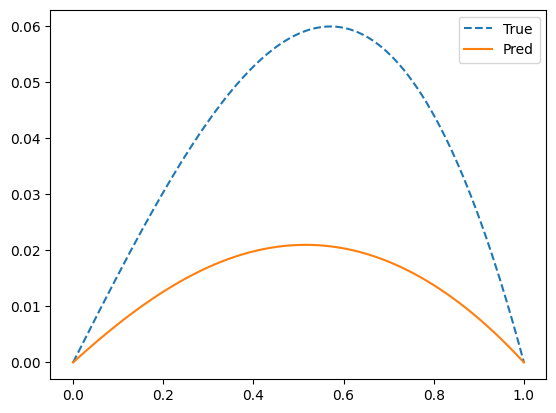

In [17]:
# Verify Solution

u_true = np.sin(x_plot_np) - x_plot_np * np.sin(1)

plt.plot(x_plot_np, u_true, '--', label='True')
plt.plot(x_plot_np, u_pred[0], label='Pred')
plt.legend()

$u′(x) + u(x) = f(x)$, $x ∈ (0,1)$\
$u(0) = 0$

In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"[INFO] Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"[INFO] CUDA not available -> using CPU")

[INFO] CUDA not available -> using CPU


In [19]:
def sample_polynomial_coeffs(batch_size: int, degree: int = 3, scale: float = 0.1):
    # shape: (batch, degree+1)
    # distribution can be changed
    return scale * torch.randn(batch_size, degree + 1, device = device)


def eval_polynomial(coeffs: torch.Tensor, x: torch.Tensor):
    """
    coeffs: (B, D+1)
    x: (N, 1) or (B, N, 1)
    returns f: (B, N, 1)
    """
    B, D1 = coeffs.shape
    D = D1 - 1

    if x.dim() == 2:
        # x: (N, 1) -> broadcast to (B, N, 1)
        x = x.unsqueeze(0).repeat(B, 1, 1)

    # powers: (B, N, D+1)
    powers = torch.cat([x**k for k in range(D + 1)], dim = -1)
    #coeffs: (B, 1, D+1)
    c = coeffs.unsqueeze(1)
    f = (powers * c).sum(dim = -1, keepdim = True)
    return f

In [20]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, activation = nn.Tanh):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), activation()]
            prev = h
        layers += [nn.Linear(prev, output_dim)]
        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)


class DeepONet(nn.Module):
    def __init__(self, m_sensors: int, p: int = 32):
        super().__init__()
        # Branch: R^m -> R^p
        self.branch = MLP(input_dim = m_sensors, hidden = [64, 64], output_dim = p, activation = nn.Tanh)
        # Trunk: R^1 -> R^p
        self.trunk = MLP(input_dim = 1, hidden = [64, 64], output_dim = p, activation = nn.Tanh)


    def forward(self, f_sensors, x):
        """
        f_sensors: (B, m)
        x: (N, 1) or (B, N, 1)
        returns u: (B, N, 1)
        """
        B = f_sensors.shape[0]

        # trunk features at x
        if x.dim() == 2:
            # (N, 1) -> (B, N, 1)
            x_in = x.unsqueeze(0).repeat(B, 1, 1)
        else:
            x_in = x

        # (B, p)
        b = self.branch(f_sensors)
        # (B, N, p)
        t = self.trunk(x_in)

        # Dot product over p: (B, N)
        u = (t * b.unsqueeze(1)).sum(dim = -1, keepdim = True)

        # Hard-enforce u(0)=u(1)=0 via output transform:
        # u_hat(x) = x(1-x) * u_row(x)
        # u = x_in * (1.0 - x_in) * u         # No hard contraint that enforce two BC, we have only one here
        return u

In [21]:
# def second_derivative(u, x):
#     """
#     u: (B, N, 1) depends on x (B, N, 1) with requries_grad = True
#     returns u_xx: (B, N, 1)
#     """
#     # First derivative
#     du_dx = torch.autograd.grad(
#         outputs = u,
#         inputs = x,
#         grad_outputs = torch.ones_like(u),
#         create_graph = True,
#         retain_graph = True,
#     )[0]

#     # Second derivative
#     d2u_dx2 = torch.autograd.grad(
#         outputs = du_dx,
#         inputs = x,
#         grad_outputs = torch.ones_like(du_dx),
#         create_graph = True,
#         retain_graph = True,
#     )[0]

#     return d2u_dx2

In [22]:
def first_derivative(u, x):
    du_dx = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]
    return du_dx

In [23]:
torch.manual_seed(0)
np.random.seed(0)

# sensors and collection points
m = 10                         # number of sensors (like DeepXDE eval points)
p = 32                         # latent width in DeepONet
N_domain = 100                 # collection points for PDE residuals
batch_size = 64                # number of functions per step

# fixed sensor locations
x_sensors = torch.linspace(0, 1, m, device = device).view(-1, 1)

# fixed domain collation locations
x_domain = torch.linspace(0, 1, N_domain, device = device).view(-1, 1)

model = DeepONet(m_sensors = m, p = p).to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

# weights
w_pde = 1.0
w_bc = 10.0

In [24]:
def train_step():
    model.train()
    optimizer.zero_grad()

    # sample a batch of random polynomials f
    coeffs = sample_polynomial_coeffs(batch_size = batch_size, degree = 3, scale = 1.0)

    # evaluate f at sensors -> branch input
    f_sensors_vals = eval_polynomial(coeffs, x_sensors).squeeze(-1)    # (B, m)

    # evaaluate f on domain points for PDE residuals
    f_domain = eval_polynomial(coeffs, x_domain)        # (B, N, 1)


    # prepare x for autograd
    x_in = x_domain.unsqueeze(0).repeat(batch_size, 1, 1).clone().detach().requires_grad_(True)

    # predict u
    u = model(f_sensors_vals, x_in)    # (B, N, 1)

    # PDE residual: u_x + u - f_domain
    u_x = first_derivative(u, x_in)
    res = u_x + u - f_domain
    loss_pde = (res ** 2).mean()

    # BC loss (should already be satisfied by transforms, but keep as sanity)
    x0 = torch.zeros(batch_size, 1, 1, device = device, requires_grad = False)
    x1 = torch.ones(batch_size, 1, 1, device = device, requires_grad = False)
    u0 = model(f_sensors_vals, x0)    # (B, 1, 1)
    u1 = model(f_sensors_vals, x1)   # (B, 1, 1)
    loss_bc = (u0 ** 2).mean()      # Only one BC in this case. u(0) = 0

    loss = (w_pde * loss_pde) + (w_bc * loss_bc)
    loss.backward()
    optimizer.step()

    return loss.item(), loss_pde.item(), loss_bc.item()

In [25]:
# Training Loop

steps = 5000
print_every = 500

for step in range(1, steps + 1):
    loss, lpde, lbc = train_step()
    if step % print_every == 0 or step == 1:
        print(f"Step {step:5d} | loss = {loss: .3e} | pde = {lpde: .3e} | bc = {lbc:.3e}")

Step     1 | loss =  1.707e+00 | pde =  1.662e+00 | bc = 4.476e-03
Step   500 | loss =  1.367e-02 | pde =  1.244e-02 | bc = 1.235e-04
Step  1000 | loss =  2.479e-03 | pde =  2.159e-03 | bc = 3.203e-05
Step  1500 | loss =  2.177e-03 | pde =  1.408e-03 | bc = 7.697e-05
Step  2000 | loss =  5.113e-04 | pde =  4.168e-04 | bc = 9.457e-06
Step  2500 | loss =  4.455e-04 | pde =  4.124e-04 | bc = 3.318e-06
Step  3000 | loss =  7.694e-04 | pde =  6.414e-04 | bc = 1.280e-05
Step  3500 | loss =  6.872e-04 | pde =  6.656e-04 | bc = 2.161e-06
Step  4000 | loss =  3.746e-04 | pde =  3.445e-04 | bc = 3.009e-06
Step  4500 | loss =  3.968e-04 | pde =  2.556e-04 | bc = 1.412e-05
Step  5000 | loss =  1.214e-03 | pde =  8.115e-04 | bc = 4.030e-05


In [26]:
model.eval()

# pick one function (or batch)
coeffs = sample_polynomial_coeffs(batch_size=1, degree=3, scale=1.0)

f_sensors_vals = eval_polynomial(coeffs, x_sensors).squeeze(-1)
f_domain = eval_polynomial(coeffs, x_domain)

# prepare x
x_in = x_domain.unsqueeze(0).clone().detach().requires_grad_(True)

# forward
u = model(f_sensors_vals, x_in)

# derivative
u_x = first_derivative(u, x_in)

# residual
residual = u_x + u - f_domain
print("Residual error:", residual.abs().mean().item())

Residual error: 0.004548092372715473


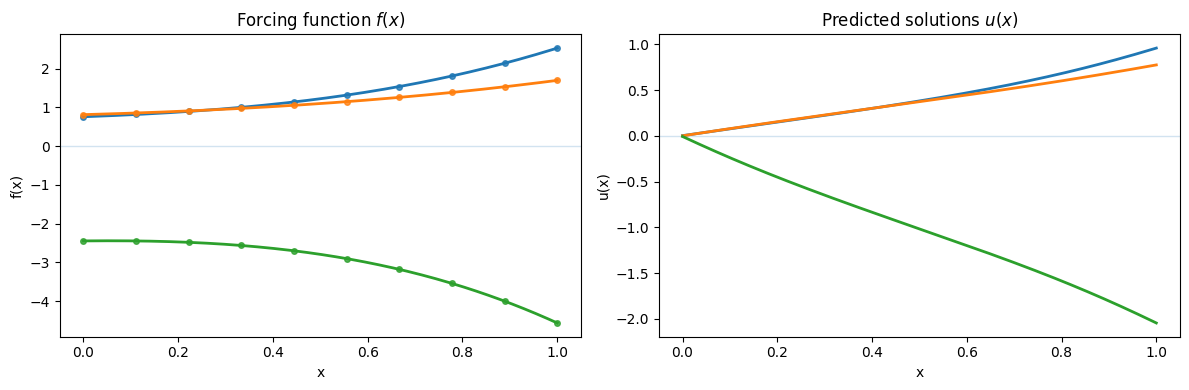

In [27]:
# Visualization of forcing functions and predicted solutions

model.eval()
n_plot = 3

# Sample random forcing functions
coeffs = sample_polynomial_coeffs(batch_size = n_plot, degree = 3, scale = 1.0)
f_sensor_vals = eval_polynomial(coeffs, x_sensors).squeeze(-1)    # (n, m)

# fine grid for plotting
x_plot = torch.linspace(0, 1, 200, device = device).view(-1, 1)

with torch.no_grad():
    u_pred = model(f_sensor_vals, x_plot)   # (n, 200, 1)

# convert to numpy for plotting
u_pred = u_pred.squeeze(-1).cpu().numpy()
f_plot = eval_polynomial(coeffs, x_plot).squeeze(-1).cpu().numpy()

x_plot_np = x_plot.squeeze(-1).cpu().numpy()
x_sensors_np = x_sensors.squeeze(-1).cpu().numpy()
f_sensors_np = eval_polynomial(coeffs, x_sensors).squeeze(-1).cpu().numpy()


# Plot f(x) and u(x) side by side with consistent colors

plt.figure(figsize = (12, 4))

# Left: forcing function
plt.subplot(1, 2, 1)
plt.title("Forcing function $f(x)$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.axhline(0, linewidth = 1, alpha = 0.2)

for i in range(n_plot):
    line, = plt.plot(x_plot_np, f_plot[i], linewidth = 2)
    plt.plot(
        x_sensors_np,
        f_sensors_np[i],
        "o",
        markersize = 4,
        color = line.get_color(),
        alpha = 0.8,
    )

# Right: predicted solutions
plt.subplot(1, 2, 2)
plt.title("Predicted solutions $u(x)$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.axhline(0, linewidth = 1, alpha = 0.2)

for i in range(n_plot):
    plt.plot(x_plot_np, u_pred[i], linewidth = 2)

plt.tight_layout()
plt.show()

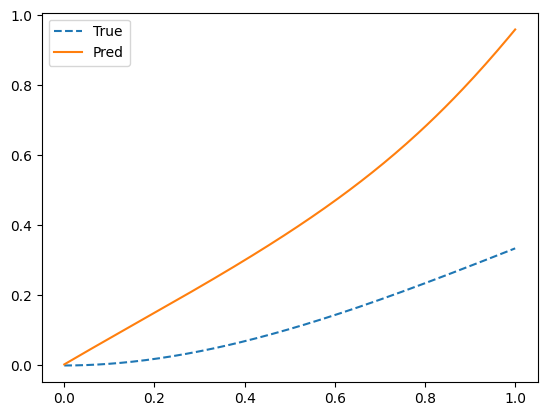

In [28]:
# Check the solution

# true solution for f(x) = sin(x)
u_true = 0.5 * (np.sin(x_plot_np) - np.cos(x_plot_np) + np.exp(-x_plot_np))

plt.plot(x_plot_np, u_true, '--', label='True')
plt.plot(x_plot_np, u_pred[0], label='Pred')
plt.legend()